# big CM MD->QM project results compilation and plotting

**Please avoid working in the original version in the DeYonker-lab-scripts repo! Copy to your own QM dir and use your local version**

This notebook pulls together everyone's data for the three active sites so it can all be plotted together.

|             | ligand | active site   | frames      | model type | parent directory for project                        |
|-------------|--------|---------------|-------------|------------|-----------------------------------------------------|
| **Dr D.**   | A:128  | A/C interface | all         | individual | /project/ndyonker/chem/cm-MD-processing/MD-QM/QM-A  |
| **Pedro**   | B:256  | B/A interface | all         | individual | /project/pssntngr/chem/chorismate_mutase/QM-B/      |
| **Haritha** | C:384  | C/B interface | all         | individual | /project/hksasi/chem/chorismate_mutase/QM-C/        |
| **Domi**    | all    | all           | every 100th | batch      | /project/dwappett/chorismate_mutase/QM-batch-models |

# Notebook environment setup: packages and default font sizes


In [1]:
import os, os.path, glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import tol_colors as tc

The following block sets up some default figure widths and font sizes to make it easier to make nice consistent figures for publication. We don't have to use them from day one but I figured it's nice to already have in here for later.

fig sizes for publications:
- single column: approx 8cm wide
- double column: approx 18cm wide


In [2]:
# set default font sizes
# use 16/18/20 for publication quality figures with widths of 8 or 18
#SMALL_SIZE = 16 
#MEDIUM_SIZE = 18 
#BIGGER_SIZE = 20 

# going to be making smaller plots for initial looks otherwise the figs are huge on a big screen. so halving the font sizes to match
SMALL_SIZE = 12
MEDIUM_SIZE = 12 
BIGGER_SIZE = 16 

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# single column figure width
scolw = 8
# double column figure width
dcolw = 18

# Read in data

In [3]:
data = {}

# get data for active site A 
pathA = '/project/ndyonker/chem/cm-MD-processing/MD-QM/QM-A'
QMAfiles = glob.glob(f'{pathA}/*/*_results.csv')
if QMAfiles:
    QMAfiles.sort()
    for f in QMAfiles:
        if QMAfiles.index(f)==0:
            data['A_ind'] = pd.read_csv(f,index_col='frame')
        else:
            data['A_ind'] = pd.concat([data['A_ind'],pd.read_csv(f,index_col='frame')])

# get data for active site B 
pathB = '/project/pssntngr/chem/chorismate_mutase/QM-B/'
QMBfiles = glob.glob(f'{pathB}/*/*_results.csv')
if QMBfiles:
    QMBfiles.sort()
    for f in QMBfiles:
        if QMBfiles.index(f)==0:
            data['B_ind'] = pd.read_csv(f,index_col='frame')
        else:
            data['B_ind'] = pd.concat([data['B_ind'],pd.read_csv(f,index_col='frame')])

# get data for active site C
pathC = '/project/hksasi/chem/chorismate_mutase/QM-C/'
QMCfiles = glob.glob(f'{pathC}/*/*_results.csv')
if QMCfiles:
    QMCfiles.sort()
    for f in QMCfiles:
        if QMCfiles.index(f)==0:
            data['C_ind'] = pd.read_csv(f,index_col='frame')
        else:
            data['C_ind'] = pd.concat([data['C_ind'],pd.read_csv(f,index_col='frame')])

# get data for batch models
pathbatch = '/project/dwappett/chorismate_mutase/QM-batch-models'
QMbatchfiles = glob.glob(f'{pathbatch}/*/*_results.csv')
if QMbatchfiles:
    QMbatchfiles.sort()
    for f in QMbatchfiles:
        if 'A128' in f:
            data['A_batch']=pd.read_csv(f,index_col='frame')
        elif 'B256' in f:
            data['B_batch']=pd.read_csv(f,index_col='frame')
        elif 'C384' in f:
            data['C_batch']=pd.read_csv(f,index_col='frame')

# add a column to each that's just the integer frame number for plotting
for key in data.keys():
    data[key].insert(loc=0, column='fnum', value=[int(i.replace('f','')) for i in data[key].index.values])

# combine all individual models into one big data set in case we want to plot that
data['all_ind'] = pd.concat([data['A_ind'],data['B_ind'],data['C_ind']])


In [4]:
# show which data sets we've got some values for
data.keys()

dict_keys(['A_ind', 'B_ind', 'C_ind', 'B_batch', 'C_batch', 'all_ind'])

In [5]:
# define labels, max and min values so that we can easily set axes titles/legend values and axes limits consistently in plots
# keys of this dict are the column labels from the csv file/dataframes

plotopts = {'dGa': {'longlabel': r'$\Delta G ^\ddagger$ (kcal/mol)',
                'shortlabel': r'$\Delta G ^\ddagger$',
                'max': max([data[key]['dGa'].max() for key in data.keys()]), 
                'min': min([data[key]['dGa'].min() for key in data.keys()])
                },
        'dGr': {'longlabel': r'$\Delta G _{rxn}$ (kcal/mol)',
                'shortlabel': r'$\Delta G _{rxn}$',
                'max': max([data[key]['dGr'].max() for key in data.keys()]), 
                'min': min([data[key]['dGr'].min() for key in data.keys()])
                },
        'size': {'longlabel': 'model size (no. atoms)',
                'shortlabel': 'size',
                'max': max([data[key]['size'].max() for key in data.keys()]), 
                'min': min([data[key]['size'].min() for key in data.keys()])
                },
        'charge': {'longlabel': 'overall charge',
                'shortlabel': 'charge',
                'max': max([data[key]['charge'].max() for key in data.keys()]), 
                'min': min([data[key]['charge'].min() for key in data.keys()])
                },
        'fnum': {'longlabel': 'frame used to create model',
                'shortlabel': 'frame',
                'max': max([data[key]['fnum'].max() for key in data.keys()]), 
                'min': min([data[key]['fnum'].min() for key in data.keys()])
                }
        }

ligands = ['A:128','B:256','C:384']

# 1) Results for individual models

## 1a) active site A

In [7]:
data['A_ind']

,fnum,ligand,size,charge,reactant,product,dGa,dGr,ts_path,ts_elE,...,react_Gkcal,prod_path,prod_elE,prod_elE+ZPE,prod_thrmE,prod_H,prod_G,prod_Nbasis,prod_Nimag,prod_Gkcal
frame,,,,,,,,,,,,,,,,,,,,,
f00001,1,A:128,217,0,irc2,irc1,15.556004,-11.072019,/project/ndyonker/chem/cm-MD-processing/MD-QM/...,-310.199662,...,-193692.767624,/project/ndyonker/chem/cm-MD-processing/MD-QM/...,-310.240921,-308.498271,-308.394756,-308.393812,-308.686459,=504,Nimag=0,-193703.839642
f00002,2,A:128,239,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f00003,3,A:128,245,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f00004,4,A:128,235,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f00005,5,A:128,266,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f00096,96,A:128,241,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f00097,97,A:128,247,1,irc1,irc2,14.201976,-11.590241,/project/ndyonker/chem/cm-MD-processing/MD-QM/...,-346.159427,...,-216097.649454,/project/ndyonker/chem/cm-MD-processing/MD-QM/...,-346.202481,-344.191233,-344.072742,-344.071798,-344.391706,=564,Nimag=0,-216109.239696
f00098,98,A:128,267,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


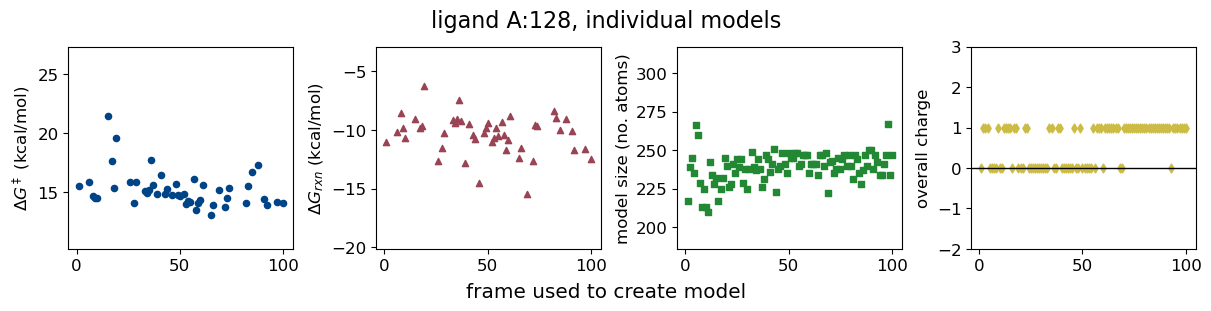

In [8]:
colours = [tc.medium_contrast.dark_blue,tc.medium_contrast.dark_red,tc.bright.green,tc.bright.yellow]
markers = ['o','^','s','d']

fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(12,3),layout='constrained')
for i, ydata in enumerate(['dGa','dGr','size','charge']):
    axs[i].axhline(y=0,color='black',linewidth=1)
    data['A_ind'].plot(x='fnum',y=ydata,kind='scatter',ax=axs[i],color=colours[i],marker=markers[i])
    axs[i].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
    axs[i].set_xlabel(None)
    axs[i].set_ylabel(plotopts[ydata]['longlabel'])

fig.supxlabel(plotopts['fnum']['longlabel'])
fig.suptitle('ligand A:128, individual models')
fig.align_labels()

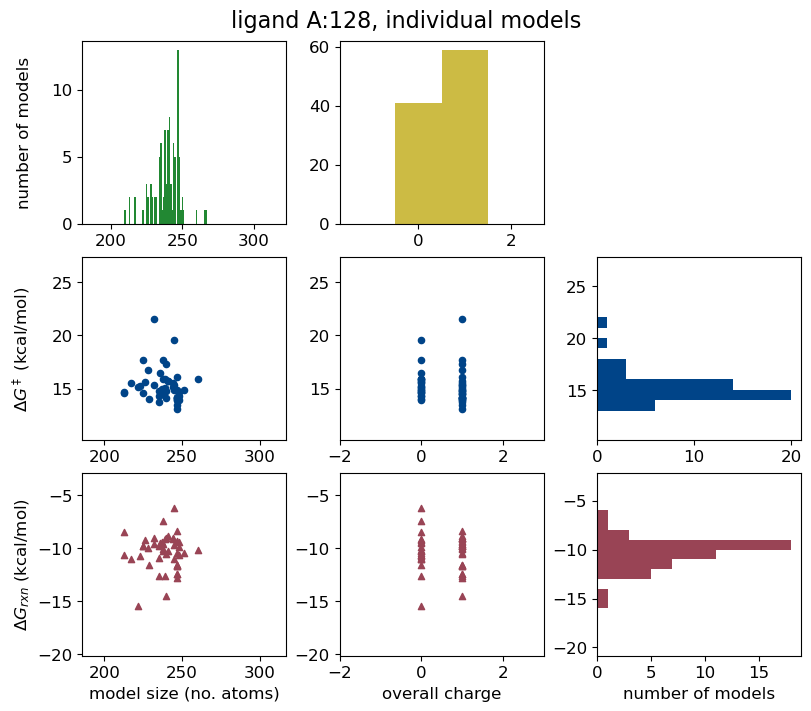

In [9]:
colours = [tc.medium_contrast.dark_blue,tc.medium_contrast.dark_red,tc.bright.green,tc.bright.yellow]
markers = ['o','^']

fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(8,7),layout='constrained')
axs[0,2].axis("off")

for i, ydata in enumerate(['dGa','dGr']):
    for j, xdata in enumerate(['size','charge']):
        axs[i+1,j].axhline(y=0,color='black',linewidth=1)
        data['A_ind'].plot(x=xdata,y=ydata,kind='scatter',ax=axs[i+1,j],color=colours[i],marker=markers[i])
        axs[i+1,j].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
        axs[i+1,j].set_xlim(left=plotopts[xdata]['min']-1,right=plotopts[xdata]['max']+1)
        axs[i+1,j].set_xlabel(None)
        axs[i+1,j].set_ylabel(None)
        # histograms of size/charge
        if i==0:
            binrange = np.arange(np.floor(plotopts[xdata]['min'])-0.5, np.ceil(plotopts[xdata]['max'])+1.5,1)
            data['A_ind'].hist(column=xdata,
                        ax=axs[i,j],
                        bins=binrange,
                        legend=False, 
                        grid=False,
                        color=colours[j+2])
            #axs[i,j].set_ylim(bottom=0,top=100)
            axs[i,j].set_title(None)
    # histograms of deltaGs
    binrange = np.arange(np.floor(plotopts[ydata]['min']), np.ceil(plotopts[ydata]['max'])+1,1)
    data['A_ind'].hist(column=ydata,
                        ax=axs[i+1,2],
                        bins=binrange,
                        legend=False, 
                        grid=False,
                        color=colours[i],
                        orientation='horizontal')
    #axs[i+1,2].set_xlim(left=0,right=100)
    axs[i+1,2].set_title(None)

axs[1,0].set_ylabel(plotopts['dGa']['longlabel'])
axs[2,0].set_ylabel(plotopts['dGr']['longlabel'])
axs[2,0].set_xlabel(plotopts['size']['longlabel'])
axs[2,1].set_xlabel(plotopts['charge']['longlabel'])

axs[0,0].set_ylabel('number of models')
axs[2,2].set_xlabel('number of models')

fig.suptitle('ligand A:128, individual models')
fig.align_labels()

In [ ]:
df = data['A_ind']

fig, axs = plt.subplots(nrows=2,ncols=4,figsize=(10,5),layout='constrained')
cols=[tc.high_contrast.yellow,tc.high_contrast.red,tc.high_contrast.blue]
for i,v in enumerate(['rms_ts-r_all','rms_ts-r_prot','rms_ts-r_wat']):
    df.plot(x='fnum',y=v,kind='scatter',ax=axs[0,0],color=cols[i],label=v.split('_')[-1])
    df.plot(x=v,y='dGa',kind='scatter',ax=axs[0,i+1],color=cols[i],xlabel=v,ylabel=plotopts['dGa']['longlabel'],xlim=(0,1))

for i,v in enumerate(['rms_p-r_all','rms_p-r_prot','rms_p-r_wat']):
    df.plot(x='fnum',y=v,kind='scatter',ax=axs[1,0],color=cols[i],label=v.split('_')[-1])
    df.plot(x=v,y='dGr',kind='scatter',ax=axs[1,i+1],color=cols[i],xlabel=v,ylabel=plotopts['dGr']['longlabel'],xlim=(0,2))


axs[0,0].set_xlabel('frame number')
axs[1,0].set_xlabel('frame number')
axs[0,0].set_ylabel('rmsd between ts and r')
axs[1,0].set_ylabel('rmsd between p and r')
axs[0,0].set_xlim(left=plotopts['fnum']['min']-1,right=plotopts['fnum']['max']+1)
axs[1,0].set_xlim(left=plotopts['fnum']['min']-1,right=plotopts['fnum']['max']+1)


fig.align_labels()

## 1b) active site B

In [10]:
data['B_ind']

,fnum,ligand,size,charge,reactant,product,dGa,dGr,ts_path,ts_elE,...,react_Gkcal,prod_path,prod_elE,prod_elE+ZPE,prod_thrmE,prod_H,prod_G,prod_Nbasis,prod_Nimag,prod_Gkcal
frame,,,,,,,,,,,,,,,,,,,,,
f00001,1,B:256,235,1,irc2,irc1,15.039513,-10.389627,/project/pssntngr/chem/chorismate_mutase/QM-B/...,-325.805453,...,-203377.357541,/project/pssntngr/chem/chorismate_mutase/QM-B/...,-325.845821,-323.928339,-323.821808,-323.820864,-324.118735,=540,Nimag=0,-203387.747168
f00002,2,B:256,256,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f00003,3,B:256,240,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f00004,4,B:256,247,2,irc1,irc2,13.086395,-10.802898,/project/pssntngr/chem/chorismate_mutase/QM-B/...,-344.611191,...,-215122.101826,/project/pssntngr/chem/chorismate_mutase/QM-B/...,-344.650483,-342.639302,-342.525470,-342.524526,-342.835819,=573,Nimag=0,-215132.904724
f00005,5,B:256,235,1,irc1,irc2,13.578055,-11.714589,/project/pssntngr/chem/chorismate_mutase/QM-B/...,-325.777572,...,-203364.891132,/project/pssntngr/chem/chorismate_mutase/QM-B/...,-325.819613,-323.906539,-323.796651,-323.795706,-324.100980,=540,Nimag=0,-203376.605721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f00096,96,B:256,248,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f00097,97,B:256,242,0,irc1,irc2,15.610202,-9.428149,/project/pssntngr/chem/chorismate_mutase/QM-B/...,-349.668526,...,-218339.829883,/project/pssntngr/chem/chorismate_mutase/QM-B/...,-349.708890,-347.765124,-347.650549,-347.649605,-347.961400,=568,Nimag=0,-218349.258032
f00098,98,B:256,239,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


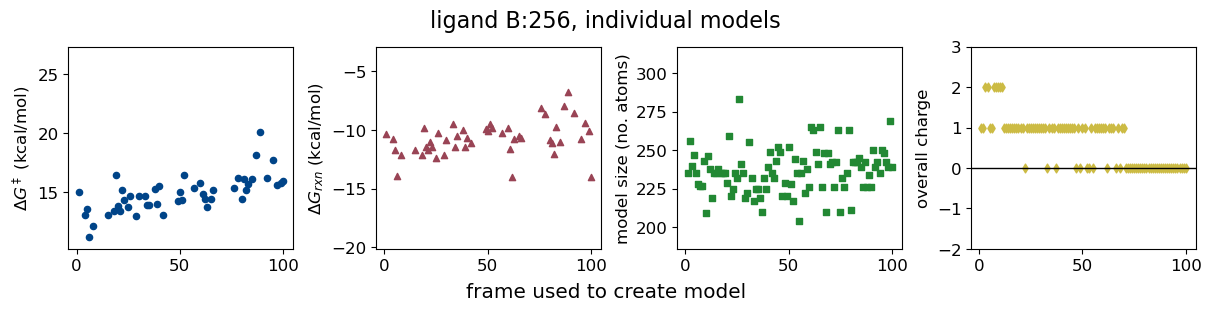

In [11]:
colours = [tc.medium_contrast.dark_blue,tc.medium_contrast.dark_red,tc.bright.green,tc.bright.yellow]
markers = ['o','^','s','d']

fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(12,3),layout='constrained')
for i, ydata in enumerate(['dGa','dGr','size','charge']):
    axs[i].axhline(y=0,color='black',linewidth=1)
    data['B_ind'].plot(x='fnum',y=ydata,kind='scatter',ax=axs[i],color=colours[i],marker=markers[i])
    axs[i].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
    axs[i].set_xlabel(None)
    axs[i].set_ylabel(plotopts[ydata]['longlabel'])

fig.supxlabel(plotopts['fnum']['longlabel'])
fig.suptitle('ligand B:256, individual models')
fig.align_labels()

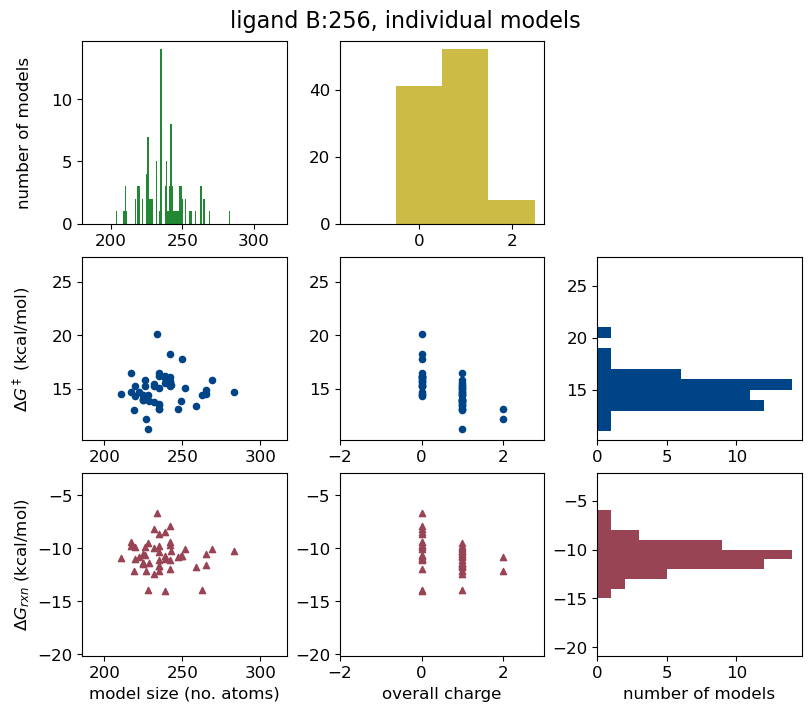

In [12]:
colours = [tc.medium_contrast.dark_blue,tc.medium_contrast.dark_red,tc.bright.green,tc.bright.yellow]
markers = ['o','^']

fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(8,7),layout='constrained')
axs[0,2].axis("off")

for i, ydata in enumerate(['dGa','dGr']):
    for j, xdata in enumerate(['size','charge']):
        axs[i+1,j].axhline(y=0,color='black',linewidth=1)
        data['B_ind'].plot(x=xdata,y=ydata,kind='scatter',ax=axs[i+1,j],color=colours[i],marker=markers[i])
        axs[i+1,j].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
        axs[i+1,j].set_xlim(left=plotopts[xdata]['min']-1,right=plotopts[xdata]['max']+1)
        axs[i+1,j].set_xlabel(None)
        axs[i+1,j].set_ylabel(None)
        # histograms of size/charge
        if i==0:
            binrange = np.arange(np.floor(plotopts[xdata]['min'])-0.5, np.ceil(plotopts[xdata]['max'])+1.5,1)
            data['B_ind'].hist(column=xdata,
                        ax=axs[i,j],
                        bins=binrange,
                        legend=False, 
                        grid=False,
                        color=colours[j+2])
            #axs[i,j].set_ylim(bottom=0,top=100)
            axs[i,j].set_title(None)
    # histograms of deltaGs
    binrange = np.arange(np.floor(plotopts[ydata]['min']), np.ceil(plotopts[ydata]['max'])+1,1)
    data['B_ind'].hist(column=ydata,
                        ax=axs[i+1,2],
                        bins=binrange,
                        legend=False, 
                        grid=False,
                        color=colours[i],
                        orientation='horizontal')
    #axs[i+1,2].set_xlim(left=0,right=100)
    axs[i+1,2].set_title(None)

axs[1,0].set_ylabel(plotopts['dGa']['longlabel'])
axs[2,0].set_ylabel(plotopts['dGr']['longlabel'])
axs[2,0].set_xlabel(plotopts['size']['longlabel'])
axs[2,1].set_xlabel(plotopts['charge']['longlabel'])

axs[0,0].set_ylabel('number of models')
axs[2,2].set_xlabel('number of models')

fig.suptitle('ligand B:256, individual models')
fig.align_labels()

In [ ]:
df = data['B_ind']

fig, axs = plt.subplots(nrows=2,ncols=4,figsize=(10,5),layout='constrained')
cols=[tc.high_contrast.yellow,tc.high_contrast.red,tc.high_contrast.blue]
for i,v in enumerate(['rms_ts-r_all','rms_ts-r_prot','rms_ts-r_wat']):
    df.plot(x='fnum',y=v,kind='scatter',ax=axs[0,0],color=cols[i],label=v.split('_')[-1])
    df.plot(x=v,y='dGa',kind='scatter',ax=axs[0,i+1],color=cols[i],xlabel=v,ylabel=plotopts['dGa']['longlabel'],xlim=(0,1))

for i,v in enumerate(['rms_p-r_all','rms_p-r_prot','rms_p-r_wat']):
    df.plot(x='fnum',y=v,kind='scatter',ax=axs[1,0],color=cols[i],label=v.split('_')[-1])
    df.plot(x=v,y='dGr',kind='scatter',ax=axs[1,i+1],color=cols[i],xlabel=v,ylabel=plotopts['dGr']['longlabel'],xlim=(0,2))


axs[0,0].set_xlabel('frame number')
axs[1,0].set_xlabel('frame number')
axs[0,0].set_ylabel('rmsd between ts and r')
axs[1,0].set_ylabel('rmsd between p and r')
axs[0,0].set_xlim(left=plotopts['fnum']['min']-1,right=plotopts['fnum']['max']+1)
axs[1,0].set_xlim(left=plotopts['fnum']['min']-1,right=plotopts['fnum']['max']+1)


fig.align_labels()

## 1c) active site C

In [13]:
data['C_ind']

,fnum,ligand,size,charge,reactant,product,dGa,dGr,ts_path,ts_elE,...,react_Gkcal,prod_path,prod_elE,prod_elE+ZPE,prod_thrmE,prod_H,prod_G,prod_Nbasis,prod_Nimag,prod_Gkcal
frame,,,,,,,,,,,,,,,,,,,,,
f00001,1,C:384,222,0,irc1,irc2,14.618165,-9.999548,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-314.729514,...,-196505.222520,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-314.768782,-312.973675,-312.864888,-312.863944,-313.166678,=512,Nimag=0,-196515.222068
f00002,2,C:384,219,0,irc1,irc2,15.025683,-11.419308,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-309.639407,...,-193322.372354,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-309.681498,-307.908010,-307.803743,-307.802799,-308.096750,=506,Nimag=0,-193333.791662
f00003,3,C:384,250,-1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f00004,4,C:384,222,0,irc2,irc1,14.395230,-11.527127,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-314.726889,...,-196503.483778,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-314.766971,-312.972287,-312.863615,-312.862671,-313.166341,=512,Nimag=0,-196515.010904
f00005,5,C:384,215,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f00096,96,C:384,215,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f00097,97,C:384,219,0,irc1,irc2,15.186733,-11.361734,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-315.421531,...,-196961.363116,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-315.461810,-313.702507,-313.593784,-313.592840,-313.895754,=506,Nimag=0,-196972.724850
f00098,98,C:384,228,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


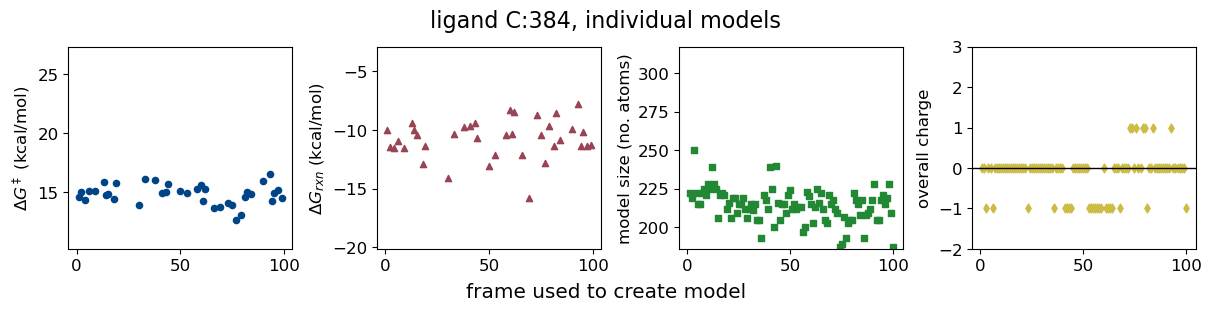

In [14]:
colours = [tc.medium_contrast.dark_blue,tc.medium_contrast.dark_red,tc.bright.green,tc.bright.yellow]
markers = ['o','^','s','d']

fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(12,3),layout='constrained')
for i, ydata in enumerate(['dGa','dGr','size','charge']):
    axs[i].axhline(y=0,color='black',linewidth=1)
    data['C_ind'].plot(x='fnum',y=ydata,kind='scatter',ax=axs[i],color=colours[i],marker=markers[i])
    axs[i].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
    axs[i].set_xlabel(None)
    axs[i].set_ylabel(plotopts[ydata]['longlabel'])

fig.supxlabel(plotopts['fnum']['longlabel'])
fig.suptitle('ligand C:384, individual models')
fig.align_labels()

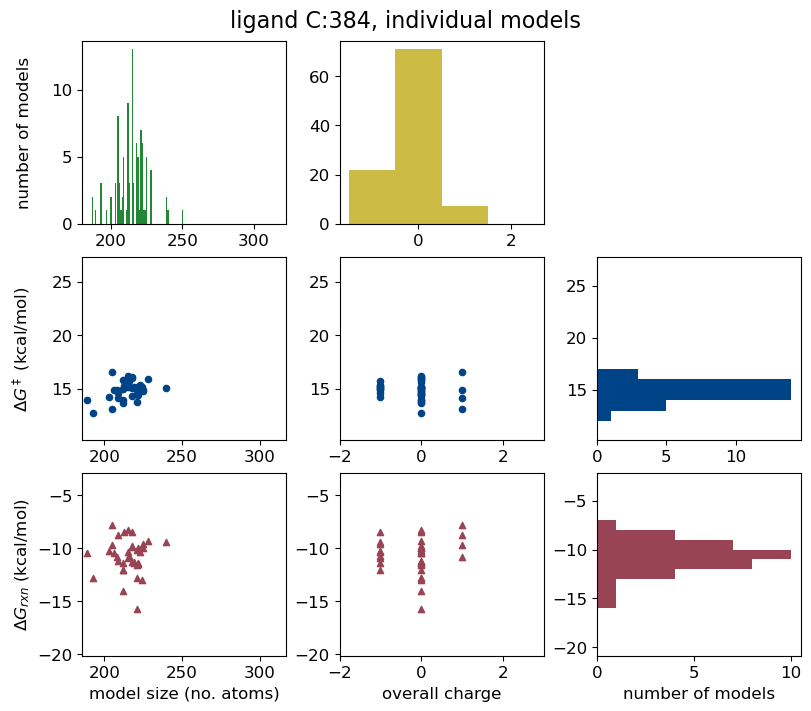

In [15]:
colours = [tc.medium_contrast.dark_blue,tc.medium_contrast.dark_red,tc.bright.green,tc.bright.yellow]
markers = ['o','^']

fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(8,7),layout='constrained')
axs[0,2].axis("off")

for i, ydata in enumerate(['dGa','dGr']):
    for j, xdata in enumerate(['size','charge']):
        axs[i+1,j].axhline(y=0,color='black',linewidth=1)
        data['C_ind'].plot(x=xdata,y=ydata,kind='scatter',ax=axs[i+1,j],color=colours[i],marker=markers[i])
        axs[i+1,j].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
        axs[i+1,j].set_xlim(left=plotopts[xdata]['min']-1,right=plotopts[xdata]['max']+1)
        axs[i+1,j].set_xlabel(None)
        axs[i+1,j].set_ylabel(None)
        # histograms of size/charge
        if i==0:
            binrange = np.arange(np.floor(plotopts[xdata]['min'])-0.5, np.ceil(plotopts[xdata]['max'])+1.5,1)
            data['C_ind'].hist(column=xdata,
                        ax=axs[i,j],
                        bins=binrange,
                        legend=False, 
                        grid=False,
                        color=colours[j+2])
            #axs[i,j].set_ylim(bottom=0,top=100)
            axs[i,j].set_title(None)
    # histograms of deltaGs
    binrange = np.arange(np.floor(plotopts[ydata]['min']), np.ceil(plotopts[ydata]['max'])+1,1)
    data['C_ind'].hist(column=ydata,
                        ax=axs[i+1,2],
                        bins=binrange,
                        legend=False, 
                        grid=False,
                        color=colours[i],
                        orientation='horizontal')
    #axs[i+1,2].set_xlim(left=0,right=100)
    axs[i+1,2].set_title(None)

axs[1,0].set_ylabel(plotopts['dGa']['longlabel'])
axs[2,0].set_ylabel(plotopts['dGr']['longlabel'])
axs[2,0].set_xlabel(plotopts['size']['longlabel'])
axs[2,1].set_xlabel(plotopts['charge']['longlabel'])

axs[0,0].set_ylabel('number of models')
axs[2,2].set_xlabel('number of models')

fig.suptitle('ligand C:384, individual models')
fig.align_labels()

In [ ]:
df = data['C_ind']

fig, axs = plt.subplots(nrows=2,ncols=4,figsize=(10,5),layout='constrained')
cols=[tc.high_contrast.yellow,tc.high_contrast.red,tc.high_contrast.blue]
for i,v in enumerate(['rms_ts-r_all','rms_ts-r_prot','rms_ts-r_wat']):
    df.plot(x='fnum',y=v,kind='scatter',ax=axs[0,0],color=cols[i],label=v.split('_')[-1])
    df.plot(x=v,y='dGa',kind='scatter',ax=axs[0,i+1],color=cols[i],xlabel=v,ylabel=plotopts['dGa']['longlabel'],xlim=(0,1))

for i,v in enumerate(['rms_p-r_all','rms_p-r_prot','rms_p-r_wat']):
    df.plot(x='fnum',y=v,kind='scatter',ax=axs[1,0],color=cols[i],label=v.split('_')[-1])
    df.plot(x=v,y='dGr',kind='scatter',ax=axs[1,i+1],color=cols[i],xlabel=v,ylabel=plotopts['dGr']['longlabel'],xlim=(0,2))


axs[0,0].set_xlabel('frame number')
axs[1,0].set_xlabel('frame number')
axs[0,0].set_ylabel('rmsd between ts and r')
axs[1,0].set_ylabel('rmsd between p and r')
axs[0,0].set_xlim(left=plotopts['fnum']['min']-1,right=plotopts['fnum']['max']+1)
axs[1,0].set_xlim(left=plotopts['fnum']['min']-1,right=plotopts['fnum']['max']+1)


fig.align_labels()

## 1d) all active sites together

### as separate subplots

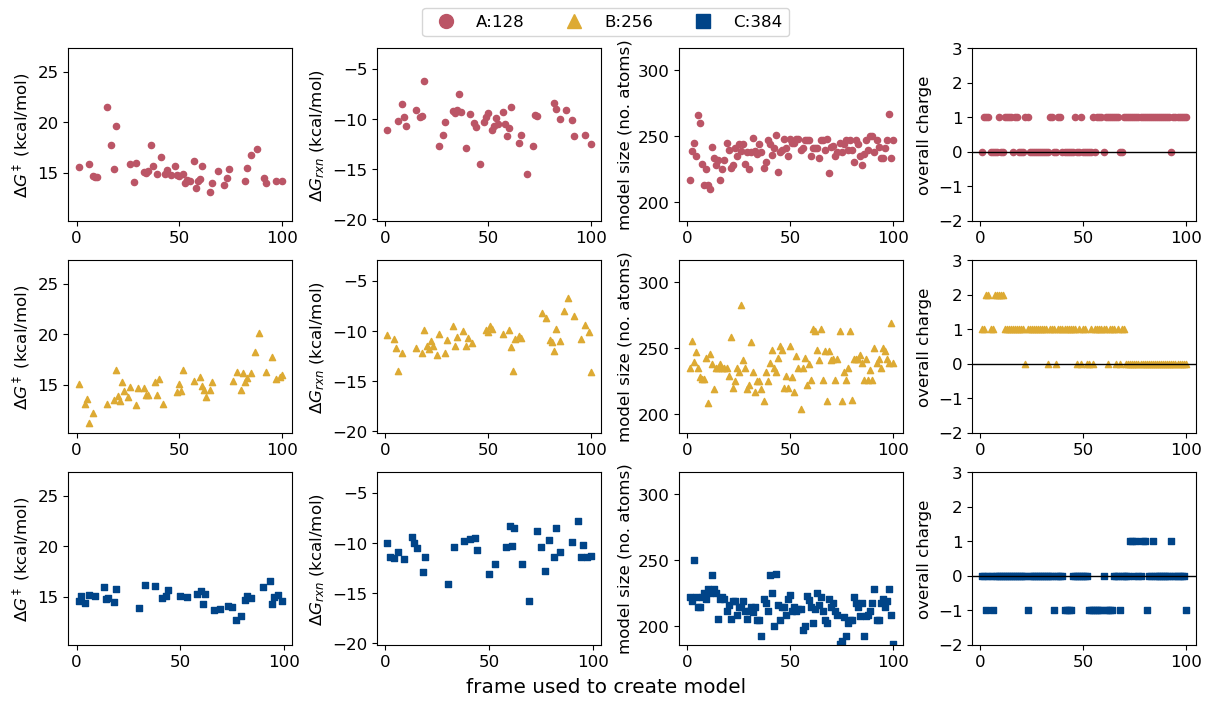

In [16]:
colours = [tc.high_contrast.red,tc.high_contrast.yellow,tc.high_contrast.blue]
markers = ['o','^','s']
ligands=['A:128','B:256','C:384']

legicons = []
fig, axs = plt.subplots(nrows=3,ncols=4,figsize=(12,7),layout='constrained')
for m, mod in enumerate(['A_ind','B_ind','C_ind']):
    if mod in data.keys():
        for i, ydata in enumerate(['dGa','dGr','size','charge']):
            axs[m,i].axhline(y=0,color='black',linewidth=1)
            data[mod].plot(x='fnum',y=ydata,kind='scatter',ax=axs[m,i],color=colours[m],marker=markers[m])
            axs[m,i].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
            axs[m,i].set_xlabel(None)
            axs[m,i].set_ylabel(plotopts[ydata]['longlabel'])
        legicons.append(matplotlib.lines.Line2D([], [], linewidth=0, color=colours[m], marker=markers[m], markersize=10, label=ligands[m]))

fig.supxlabel(plotopts['fnum']['longlabel'])
#fig.suptitle('all active sites,individual models\n')
fig.legend(handles=legicons, loc='outside upper center', ncols=3)
fig.align_labels()

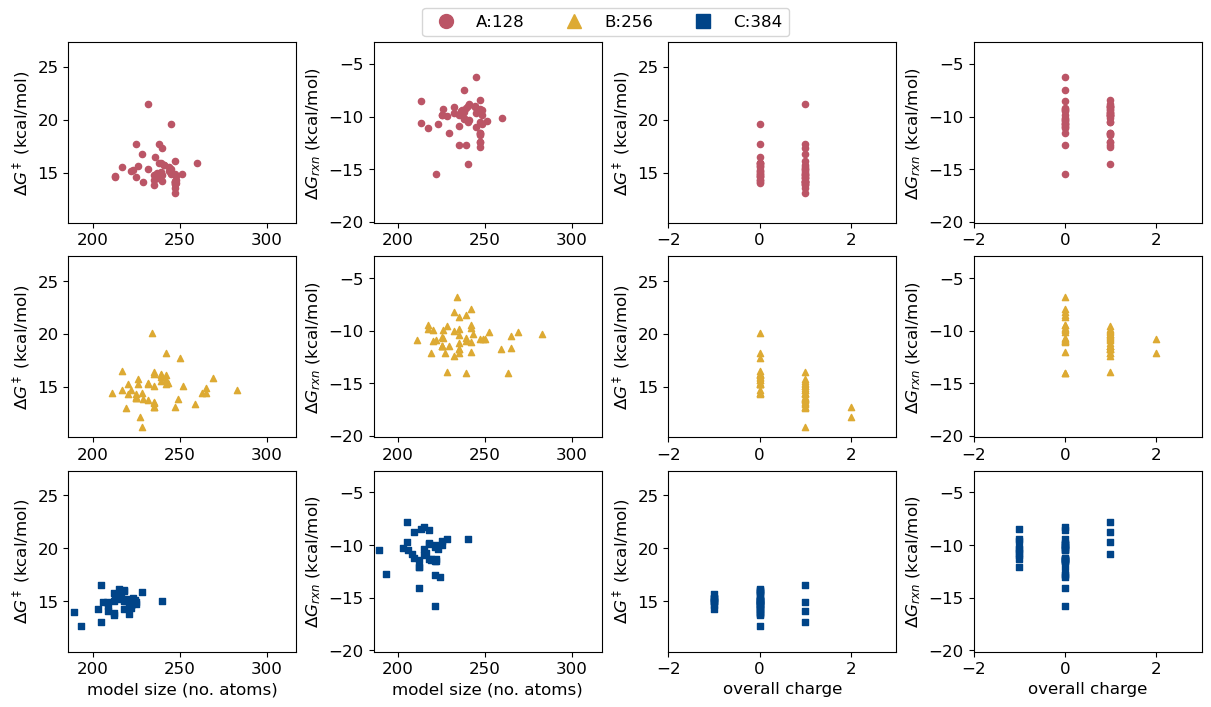

In [17]:
colours = [tc.high_contrast.red,tc.high_contrast.yellow,tc.high_contrast.blue]
markers = ['o','^','s']
ligands=['A:128','B:256','C:384']

legicons = []
fig, axs = plt.subplots(nrows=3,ncols=4,figsize=(12,7),layout='constrained')
for m, mod in enumerate(['A_ind','B_ind','C_ind']):
    if mod in data.keys():
        for i, ydata in enumerate(['dGa','dGr']):
            axs[m,i].axhline(y=0,color='black',linewidth=1)
            data[mod].plot(x='size',y=ydata,kind='scatter',ax=axs[m,i],color=colours[m],marker=markers[m])
            axs[m,i].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
            axs[m,i].set_xlim(left=plotopts['size']['min']-1,right=plotopts['size']['max']+1)
            axs[m,i].set_ylabel(plotopts[ydata]['longlabel'])
            axs[m,i+2].axhline(y=0,color='black',linewidth=1)
            data[mod].plot(x='charge',y=ydata,kind='scatter',ax=axs[m,i+2],color=colours[m],marker=markers[m])
            axs[m,i+2].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
            axs[m,i+2].set_xlim(left=plotopts['charge']['min']-1,right=plotopts['charge']['max']+1)
            axs[m,i+2].set_ylabel(plotopts[ydata]['longlabel'])
            if m==2:
                axs[m,i].set_xlabel(plotopts['size']['longlabel'])
                axs[m,i+2].set_xlabel(plotopts['charge']['longlabel'])
            else:
                axs[m,i].set_xlabel(None)
                axs[m,i+2].set_xlabel(None)
        legicons.append(matplotlib.lines.Line2D([], [], linewidth=0, color=colours[m], marker=markers[m], markersize=10, label=ligands[m]))

#fig.suptitle('all active sites,individual models\n')
fig.legend(handles=legicons, loc='outside upper center', ncols=3)
fig.align_labels()

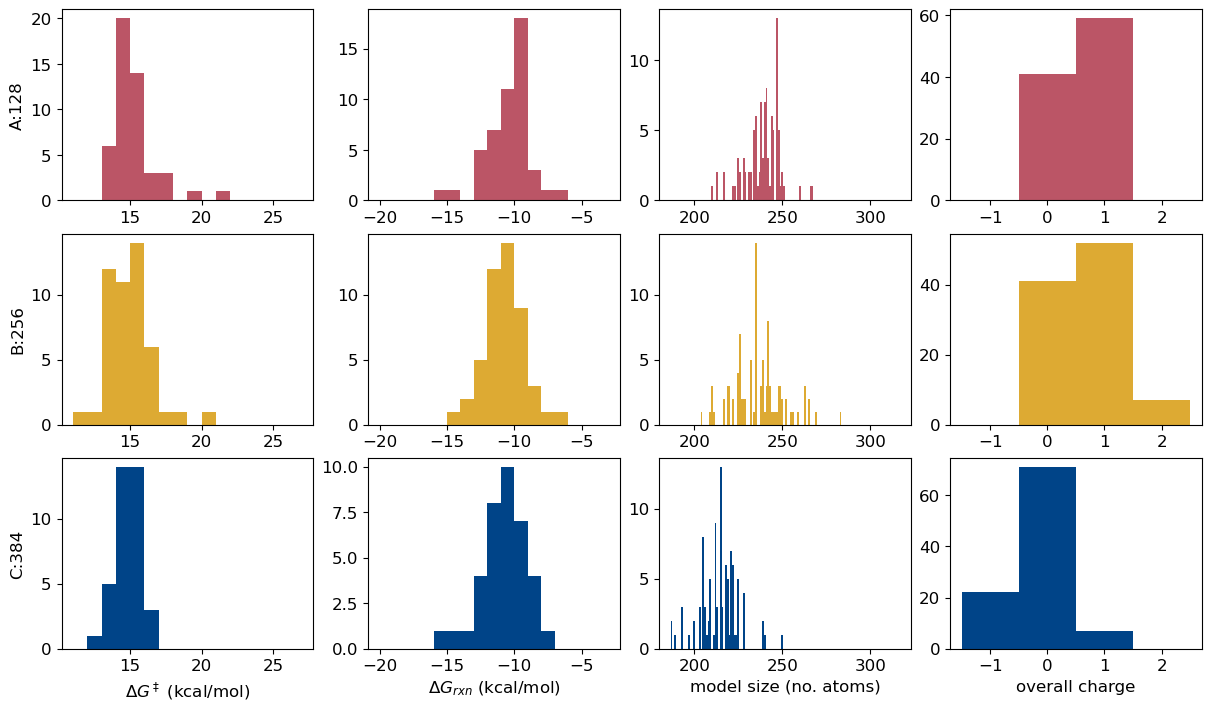

In [18]:
ligands = ['A:128','B:256','C:384']
cols = [tc.high_contrast.red,tc.high_contrast.yellow,tc.high_contrast.blue]
fig, axs = plt.subplots(nrows=3,ncols=4,figsize=(12,7),layout='constrained')
for i, mod in enumerate(['A_ind','B_ind','C_ind']):
    if mod in data.keys():
        for j, yv in enumerate(['dGa','dGr','size','charge']):
            if yv in ['size','charge']:
                binrange = np.arange(np.floor(plotopts[yv]['min'])-0.5, np.ceil(plotopts[yv]['max'])+1.5,1)
            else:
                binrange = np.arange(np.floor(plotopts[yv]['min']), np.ceil(plotopts[yv]['max'])+1,1)
            data[mod].hist(column=yv,
                        ax=axs[i,j],
                        bins=binrange,
                        legend=False, 
                        grid=False,
                        color=cols[i])
            axs[i,j].set_title(None)
            if j == 0:
                axs[i,j].set_ylabel(ligands[i])
            else:
                axs[i,j].set_ylabel(None)
            if i == 2:
                axs[i,j].set_xlabel(plotopts[yv]['longlabel'])
            else:
                axs[i,j].set_xlabel(None)

fig.align_labels()

### overlaid

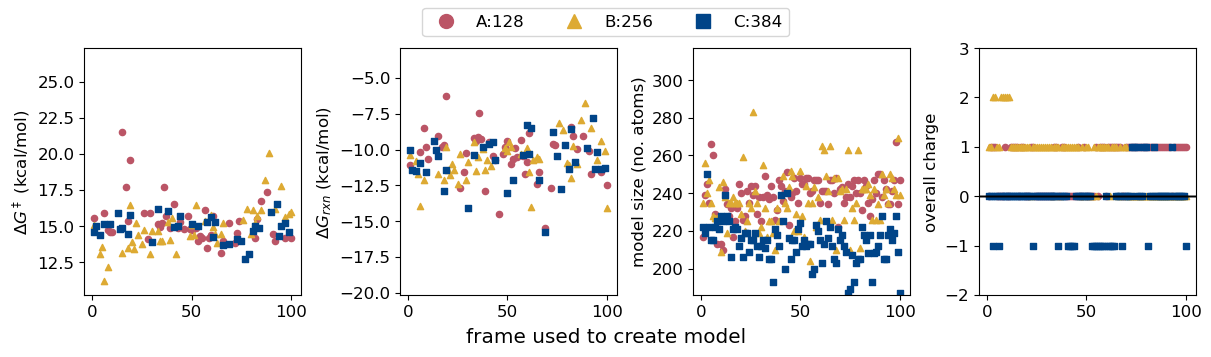

In [19]:
# results by frame, plotted with different colours for each active site

colours = [tc.high_contrast.red,tc.high_contrast.yellow,tc.high_contrast.blue]
markers = ['o','^','s']
ligands=['A:128','B:256','C:384']

legicons = []
fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(12,3.5),layout='constrained')
for m, mod in enumerate(['A_ind','B_ind','C_ind']):
    if mod in data.keys():
        for i, ydata in enumerate(['dGa','dGr','size','charge']):
            axs[i].axhline(y=0,color='black',linewidth=1)
            data[mod].plot(x='fnum',y=ydata,kind='scatter',ax=axs[i],color=colours[m],marker=markers[m])
            axs[i].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
            axs[i].set_xlabel(None)
            axs[i].set_ylabel(plotopts[ydata]['longlabel'])
        legicons.append(matplotlib.lines.Line2D([], [], linewidth=0, color=colours[m], marker=markers[m], markersize=10, label=ligands[m]))

fig.supxlabel(plotopts['fnum']['longlabel'])
#fig.suptitle('all active sites,individual models\n')
fig.legend(handles=legicons, loc='outside upper center', ncols=3)
fig.align_labels()

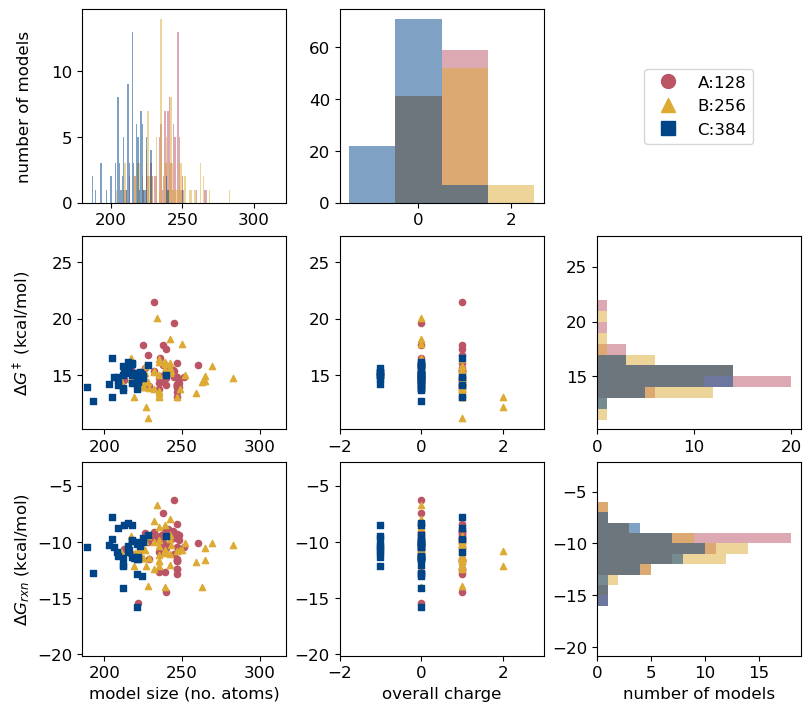

In [20]:
colours = [tc.high_contrast.red,tc.high_contrast.yellow,tc.high_contrast.blue]
markers = ['o','^','s']
ligands=['A:128','B:256','C:384']
legicons=[]

fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(8,7),layout='constrained')
axs[0,2].axis("off")

for m, mod in enumerate(['A_ind','B_ind','C_ind']):
    if mod in data.keys():
        for i, ydata in enumerate(['dGa','dGr']):
            for j, xdata in enumerate(['size','charge']):
                axs[i+1,j].axhline(y=0,color='black',linewidth=1)
                data[mod].plot(x=xdata,y=ydata,kind='scatter',ax=axs[i+1,j],color=colours[m],marker=markers[m])
                axs[i+1,j].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
                axs[i+1,j].set_xlim(left=plotopts[xdata]['min']-1,right=plotopts[xdata]['max']+1)
                axs[i+1,j].set_xlabel(None)
                axs[i+1,j].set_ylabel(None)
                # histograms of size/charge
                if i==0:
                    binrange = np.arange(np.floor(plotopts[xdata]['min'])-0.5, np.ceil(plotopts[xdata]['max'])+1.5,1)
                    data[mod].hist(column=xdata,
                                ax=axs[i,j],
                                bins=binrange,
                                legend=False, 
                                grid=False,
                                color=colours[m],
                                alpha=0.5)
                    #axs[i,j].set_ylim(bottom=0,top=100)
                    axs[i,j].set_title(None)
            # histograms of deltaGs
            binrange = np.arange(np.floor(plotopts[ydata]['min']), np.ceil(plotopts[ydata]['max'])+1,1)
            data[mod].hist(column=ydata,
                                ax=axs[i+1,2],
                                bins=binrange,
                                legend=False, 
                                grid=False,
                                color=colours[m],
                                orientation='horizontal',
                                alpha=0.5)
            #axs[i+1,2].set_xlim(left=0,right=100)
            axs[i+1,2].set_title(None)
        legicons.append(matplotlib.lines.Line2D([], [], linewidth=0, color=colours[m], marker=markers[m], markersize=10, label=ligands[m]))

axs[1,0].set_ylabel(plotopts['dGa']['longlabel'])
axs[2,0].set_ylabel(plotopts['dGr']['longlabel'])
axs[2,0].set_xlabel(plotopts['size']['longlabel'])
axs[2,1].set_xlabel(plotopts['charge']['longlabel'])

axs[0,0].set_ylabel('number of models')
axs[2,2].set_xlabel('number of models')

axs[0,2].legend(handles=legicons, loc='center')
fig.align_labels()

### combined into one set

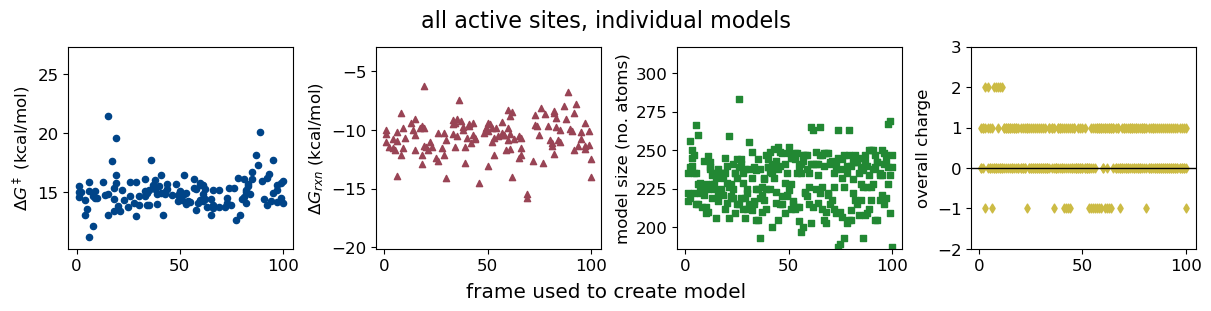

In [21]:
colours = [tc.medium_contrast.dark_blue,tc.medium_contrast.dark_red,tc.bright.green,tc.bright.yellow]
markers = ['o','^','s','d']

fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(12,3),layout='constrained')
for i, ydata in enumerate(['dGa','dGr','size','charge']):
    axs[i].axhline(y=0,color='black',linewidth=1)
    data['all_ind'].plot(x='fnum',y=ydata,kind='scatter',ax=axs[i],color=colours[i],marker=markers[i])
    axs[i].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
    axs[i].set_xlabel(None)
    axs[i].set_ylabel(plotopts[ydata]['longlabel'])

fig.supxlabel(plotopts['fnum']['longlabel'])
fig.suptitle('all active sites, individual models')
fig.align_labels()

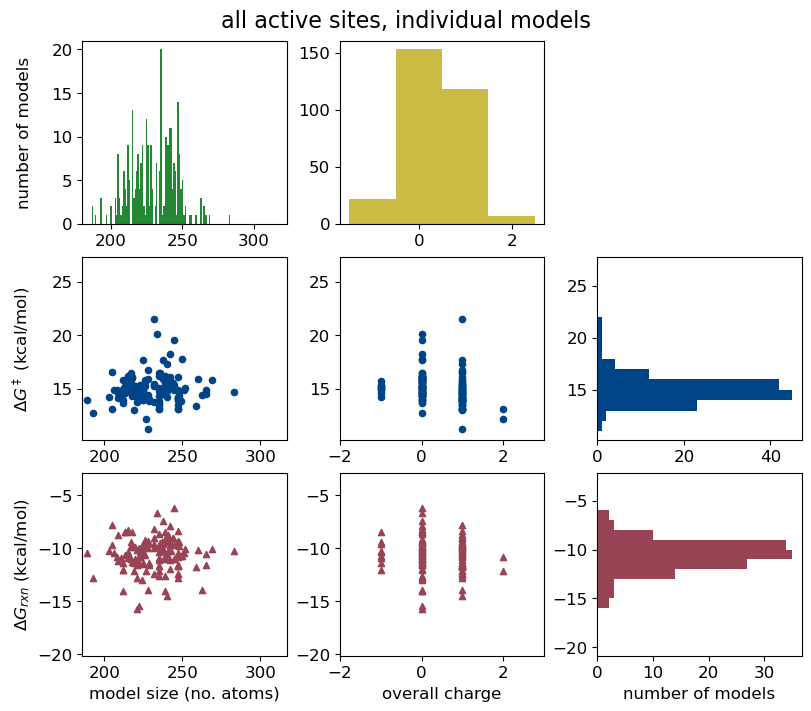

In [22]:
colours = [tc.medium_contrast.dark_blue,tc.medium_contrast.dark_red,tc.bright.green,tc.bright.yellow]
markers = ['o','^']

fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(8,7),layout='constrained')
axs[0,2].axis("off")

for i, ydata in enumerate(['dGa','dGr']):
    for j, xdata in enumerate(['size','charge']):
        axs[i+1,j].axhline(y=0,color='black',linewidth=1)
        data['all_ind'].plot(x=xdata,y=ydata,kind='scatter',ax=axs[i+1,j],color=colours[i],marker=markers[i])
        axs[i+1,j].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
        axs[i+1,j].set_xlim(left=plotopts[xdata]['min']-1,right=plotopts[xdata]['max']+1)
        axs[i+1,j].set_xlabel(None)
        axs[i+1,j].set_ylabel(None)
        # histograms of size/charge
        if i==0:
            binrange = np.arange(np.floor(plotopts[xdata]['min'])-0.5, np.ceil(plotopts[xdata]['max'])+1.5,1)
            data['all_ind'].hist(column=xdata,
                        ax=axs[i,j],
                        bins=binrange,
                        legend=False, 
                        grid=False,
                        color=colours[j+2])
            #axs[i,j].set_ylim(bottom=0,top=100)
            axs[i,j].set_title(None)
    # histograms of deltaGs
    binrange = np.arange(np.floor(plotopts[ydata]['min']), np.ceil(plotopts[ydata]['max'])+1,1)
    data['all_ind'].hist(column=ydata,
                        ax=axs[i+1,2],
                        bins=binrange,
                        legend=False, 
                        grid=False,
                        color=colours[i],
                        orientation='horizontal')
    #axs[i+1,2].set_xlim(left=0,right=100)
    axs[i+1,2].set_title(None)

axs[1,0].set_ylabel(plotopts['dGa']['longlabel'])
axs[2,0].set_ylabel(plotopts['dGr']['longlabel'])
axs[2,0].set_xlabel(plotopts['size']['longlabel'])
axs[2,1].set_xlabel(plotopts['charge']['longlabel'])

axs[0,0].set_ylabel('number of models')
axs[2,2].set_xlabel('number of models')

fig.suptitle('all active sites, individual models')
fig.align_labels()

# 2) Results for batch models

## all active sites together (as separate subplots)

All models of each active site have the same size and charge so no point plotting energies against those

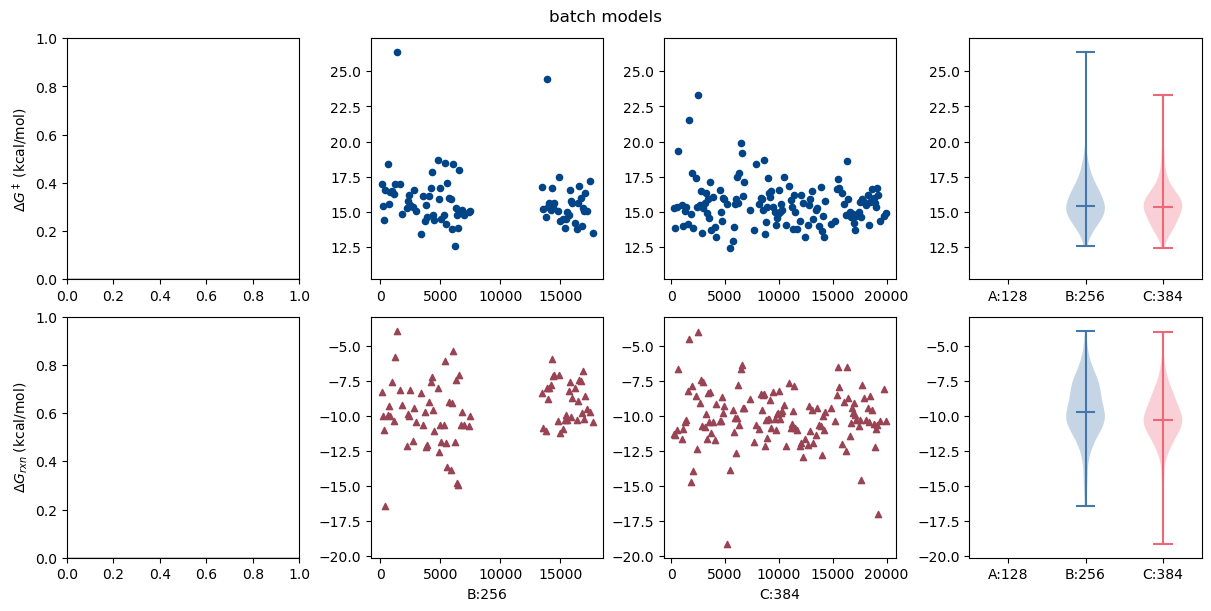

In [5]:
ligands = ['A:128','B:256','C:384']
fig, axs = plt.subplots(nrows=2,ncols=4,figsize=(12,6),layout='constrained')

actVdata = []
rxnVdata = []

for i, mod in enumerate(['A_batch','B_batch','C_batch']):
    for j in [0,1]:
        axs[j,i].axhline(y=0,color='black',linewidth=1)
    if mod in data.keys():
        data[mod].plot(x='fnum',y='dGa',kind='scatter',ax=axs[0,i],color=tc.medium_contrast.dark_blue,marker='o')
        data[mod].plot(x='fnum',y='dGr',kind='scatter',ax=axs[1,i],color=tc.medium_contrast.dark_red,marker='^')
        axs[0,i].set_ylim(bottom=plotopts['dGa']['min']-1,top=plotopts['dGa']['max']+1)
        axs[1,i].set_ylim(bottom=plotopts['dGr']['min']-1,top=plotopts['dGr']['max']+1)
        axs[0,i].set_ylabel(None)
        axs[1,i].set_ylabel(None)
        axs[0,i].set_xlabel(None)
        axs[1,i].set_xlabel(ligands[i])
        axs[0,3].violinplot(data[mod].loc[data[mod]['dGa'].notna(),'dGa'],positions=[i+1],showmedians=True)
        axs[1,3].violinplot(data[mod].loc[data[mod]['dGr'].notna(),'dGr'],positions=[i+1],showmedians=True)
        axs[0,3].set_ylim(bottom=plotopts['dGa']['min']-1,top=plotopts['dGa']['max']+1)
        axs[1,3].set_ylim(bottom=plotopts['dGr']['min']-1,top=plotopts['dGr']['max']+1)


axs[0,0].set_ylabel(plotopts['dGa']['longlabel'])
axs[1,0].set_ylabel(plotopts['dGr']['longlabel'])
axs[0,0].set_ylabel(plotopts['dGa']['longlabel'])
axs[1,0].set_ylabel(plotopts['dGr']['longlabel'])
for i in [0,1]:
    axs[i,3].set_xlim(left=0.5,right=3.5)
    axs[i,3].set_xticks([1,2,3])
    axs[i,3].set_xticklabels(ligands)

fig.suptitle('batch models')
fig.align_labels()

In [6]:
data['C_ind']

,fnum,ligand,size,charge,reactant,product,dGa,dGr,ts_path,ts_elE,...,react_Gkcal,prod_path,prod_elE,prod_elE+ZPE,prod_thrmE,prod_H,prod_G,prod_Nbasis,prod_Nimag,prod_Gkcal
frame,,,,,,,,,,,,,,,,,,,,,
f00001,1,C:384,222,0,irc1,irc2,14.618165,-9.999548,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-314.729514,...,-196505.222520,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-314.768782,-312.973675,-312.864888,-312.863944,-313.166678,=512,Nimag=0,-196515.222068
f00002,2,C:384,219,0,irc1,irc2,15.025683,-11.419308,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-309.639407,...,-193322.372354,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-309.681498,-307.908010,-307.803743,-307.802799,-308.096750,=506,Nimag=0,-193333.791662
f00003,3,C:384,250,-1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f00004,4,C:384,222,0,irc2,irc1,14.395230,-11.527127,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-314.726889,...,-196503.483778,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-314.766971,-312.972287,-312.863615,-312.862671,-313.166341,=512,Nimag=0,-196515.010904
f00005,5,C:384,215,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f00096,96,C:384,215,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f00097,97,C:384,219,0,irc1,irc2,15.186733,-11.361734,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-315.421531,...,-196961.363116,/project/hksasi/chem/chorismate_mutase/QM-C/f0...,-315.461810,-313.702507,-313.593784,-313.592840,-313.895754,=506,Nimag=0,-196972.724850
f00098,98,C:384,228,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 3) Comparing individual and batch models

## overall comparisons

Text(0, 0.5, '$\\Delta G _{rxn}$ (kcal/mol)')

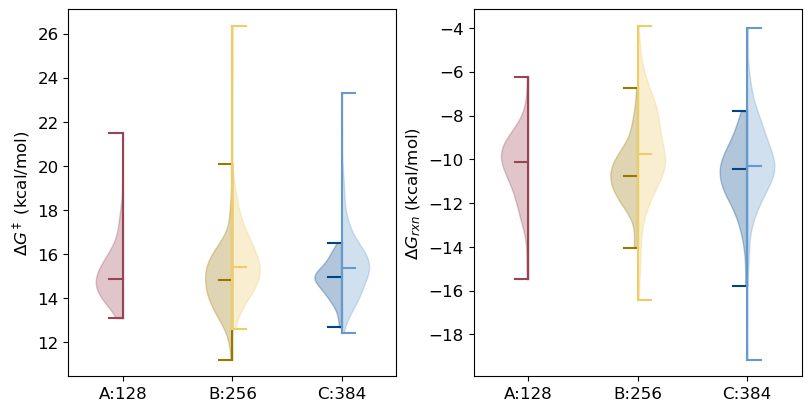

In [50]:
icols = [tc.medium_contrast.dark_red, tc.medium_contrast.dark_yellow, tc.medium_contrast.dark_blue]
bcols = [tc.medium_contrast.light_red, tc.medium_contrast.light_yellow, tc.medium_contrast.light_blue]

fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(8,4),layout='constrained')

for i, mod in enumerate(['A_ind','B_ind','C_ind']):
    if mod in data.keys():
        v1 = axs[0].violinplot(data[mod].loc[data[mod]['dGa'].notna(),'dGa'],positions=[i+1],showmedians=True,side='low')
        v2 = axs[1].violinplot(data[mod].loc[data[mod]['dGr'].notna(),'dGr'],positions=[i+1],showmedians=True,side='low')
        for pc in v1['bodies']: pc.set_color(icols[i])
        for key in ['cmaxes','cmins','cbars','cmedians']:
            v1[key].set_colors(icols[i])
        for pc in v2['bodies']: pc.set_color(icols[i])
        for key in ['cmaxes','cmins','cbars','cmedians']:
            v2[key].set_colors(icols[i])

for i, mod in enumerate(['A_batch','B_batch','C_batch']):
    if mod in data.keys():
        v1=axs[0].violinplot(data[mod].loc[data[mod]['dGa'].notna(),'dGa'],positions=[i+1],showmedians=True,side='high')
        v2=axs[1].violinplot(data[mod].loc[data[mod]['dGr'].notna(),'dGr'],positions=[i+1],showmedians=True,side='high')
        for pc in v1['bodies']: pc.set_color(bcols[i])
        for key in ['cmaxes','cmins','cbars','cmedians']:
            v1[key].set_colors(bcols[i])
        for pc in v2['bodies']: pc.set_color(bcols[i])
        for key in ['cmaxes','cmins','cbars','cmedians']:
            v2[key].set_colors(bcols[i])

for i in [0,1]:
    axs[i].set_xlim(left=0.5,right=3.5)
    axs[i].set_xticks([1,2,3])
    axs[i].set_xticklabels(ligands)

axs[0].set_ylabel(plotopts['dGa']['longlabel'])
axs[1].set_ylabel(plotopts['dGr']['longlabel'])


## frame by frame comparisons